# 06 - Course Insight Analysis

Objective:
- use the model to identify the performance level of a course
- analyze one course in depth
- identify strengths and weaknesses of students
- transform predictions into interpretable insights

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [139]:
df = pd.read_csv("../data/raw/cursos_ufjf_enade2022.csv")
courses = pd.read_csv("../data/raw/metadata/cursos_ufjf2022.csv")

courses = courses.rename(columns={"código": "CO_CURSO", "Curso": "NO_CURSO"})

df["CO_CURSO"] = pd.to_numeric(df["CO_CURSO"], errors="coerce")
courses["CO_CURSO"] = pd.to_numeric(courses["CO_CURSO"], errors="coerce")

df = df.merge(courses, on="CO_CURSO", how="left")

df = df.dropna(subset=["NT_GER"]).copy()

print(df.shape)

(813, 53)


In [140]:
df["performance"] = pd.qcut(
    df["NT_GER"],
    q=3,
    labels=["low", "medium", "high"]
)

df["performance"].value_counts()

performance
low       271
medium    271
high      271
Name: count, dtype: int64

In [141]:
features = [
    "CO_CURSO",
    "TP_PRES",
    "NU_ITEM_OFG",
    "NU_ITEM_OCE"
]

features = [col for col in features if col in df.columns]

X = pd.get_dummies(df[features], drop_first=True)
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [142]:
result = df.loc[X_test.index, ["CO_CURSO", "NO_CURSO"]].copy()

result["real"] = y_test
result["predicted"] = pred

result.head()

,CO_CURSO,NO_CURSO,real,predicted
849,27657,JORNALISMO,high,high
297,13090,CIÊNCIAS ECONÔMICAS,low,low
224,13089,DIREITO,medium,high
990,1178675,NaN,high,medium
994,1178675,NaN,high,medium


In [151]:
course_example = result["CO_CURSO"].iloc[141]

df_course = df[df["CO_CURSO"] == course_example].copy()
result_course = result[result["CO_CURSO"] == course_example].copy()

print("Course code:", course_example)
print("Course name:", df_course["NO_CURSO"].iloc[0])
print("Number of students:", len(df_course))

Course code: 21589
Course name: TURISMO
Number of students: 46


## Model Insight

The model classifies most students in this course into a specific performance level.

This gives an initial indication of how the course behaves overall.

In [144]:
analysis_vars = [
    "NT_GER",
    "NT_FG",
    "NT_CE",
    "NT_OBJ_FG",
    "NT_DIS_FG",
    "NT_OBJ_CE",
    "NT_DIS_CE"
]

analysis_vars = [col for col in analysis_vars if col in df.columns]

analysis_vars

['NT_GER',
 'NT_FG',
 'NT_CE',
 'NT_OBJ_FG',
 'NT_DIS_FG',
 'NT_OBJ_CE',
 'NT_DIS_CE']

In [145]:
df_pr = pd.read_csv("../data/processed/enade_ufjf_2022_model.csv")

if "performance" not in df_pr.columns:
    df_pr["performance"] = pd.qcut(
        df_pr["NT_GER"],
        q=3,
        labels=["low", "medium", "high"]
    )

df_pr = df_pr.merge(courses[["CO_CURSO", "NO_CURSO"]], on="CO_CURSO", how="left")

df_turismo = df_pr[df_pr["NO_CURSO"].str.contains("TURISMO", case=False, na=False)]

counts = df_turismo["performance"].value_counts()

print("Distribuição - Turismo:")
print(counts)

Distribuição - Turismo:
performance
medium    21
high      18
low        7
Name: count, dtype: int64


In [146]:
comparison = pd.DataFrame({
    "Course": df_course[analysis_vars].mean(),
    "Overall": df[analysis_vars].mean()
})

comparison["Difference"] = comparison["Course"] - comparison["Overall"]

comparison.sort_values("Difference")

,Course,Overall,Difference
NT_OBJ_FG,67.934783,72.047970,-4.113188
NT_FG,65.347826,69.139852,-3.792026
NT_DIS_FG,61.489130,64.801476,-3.312346
NT_OBJ_CE,59.104348,55.104797,3.999551
NT_GER,60.813043,56.450062,4.362982
NT_CE,59.291304,52.205412,7.085892
NT_DIS_CE,60.323913,35.743665,24.580248


In [147]:
strengths = comparison.sort_values("Difference", ascending=False).head(3)
weaknesses = comparison.sort_values("Difference", ascending=True).head(3)

print("Strengths:")
display(strengths)

print("Weaknesses:")
display(weaknesses)

Strengths:


,Course,Overall,Difference
NT_DIS_CE,60.323913,35.743665,24.580248
NT_CE,59.291304,52.205412,7.085892
NT_GER,60.813043,56.450062,4.362982


Weaknesses:


,Course,Overall,Difference
NT_OBJ_FG,67.934783,72.047970,-4.113188
NT_FG,65.347826,69.139852,-3.792026
NT_DIS_FG,61.489130,64.801476,-3.312346


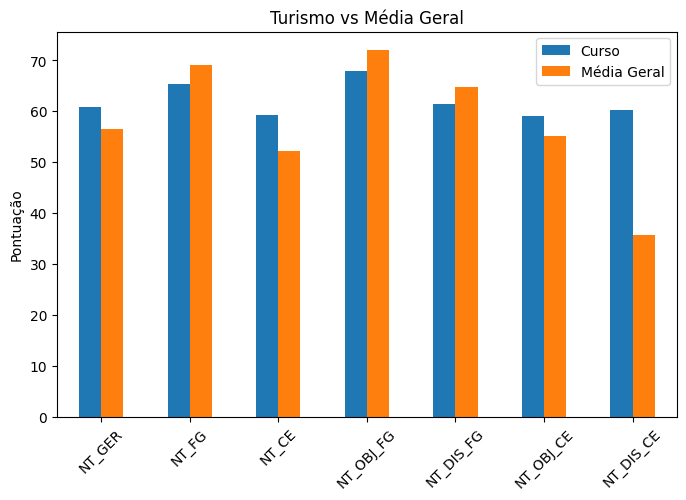

In [148]:
comparison[["Course", "Overall"]].plot(kind="bar", figsize=(8,5))

plt.title("Turismo vs Média Geral")
plt.ylabel("Pontuação")
plt.xticks(rotation=45)
plt.legend(["Curso", "Média Geral"])

plt.show()

## Course Insight

The model indicated the general performance level of the course.

To understand this result, we analyzed the internal variables.

By comparing the course with the overall average, we identified:

- areas where students perform better,
- areas where students perform worse.

Lower values in:
- NT_FG → difficulty in general knowledge
- NT_OBJ_FG → difficulty in objective general questions
- NT_DIS_FG → difficulty in discursive general questions

Higher values in:
- NT_CE → strong performance in specific knowledge
- NT_OBJ_CE → good performance in objective specific questions
- NT_DIS_CE → very strong performance in discursive specific questions

This indicates that students perform better in technical and course-specific content, but have difficulties in general knowledge.

This explains the model's prediction and highlights the main strengths and weaknesses of the course.